# FIFA World Cup 2026 — Objective 1 & Objective 2

**Objective 1** — four analytic tasks, each with a distinct focal point
(market value, experience, match performance, age) and each broken into
the six required sections, in the brief's own wording:
1. Analytic question formulation
2. Data wrangling
3. Data preparation and sampling
4. Descriptive statistics
5. Inferential statistics (Confidence interval)
6. Inferential statistics (One-Sample or Two-sample t-Test)

**Objective 2** — two linear regression models (match goal difference;
team goals per match), each using exactly 8 explanatory variables that are
all known before kickoff.

**Data source:** a CC0-licensed (public domain) FIFA World Cup 2026 dataset
loaded directly from GitHub

## Setup

In [1]:
try:
    import statsmodels
except ImportError:
    !pip install -q statsmodels

import re
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
ALPHA = 0.05
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

## Load the data

In [2]:
BASE_URL = "https://raw.githubusercontent.com/mominullptr/FIFA-World-Cup-2026-Dataset/main/"

teams_raw = pd.read_csv(BASE_URL + "teams.csv")
players_raw = pd.read_csv(BASE_URL + "squads_and_players.csv")
matches_raw = pd.read_csv(BASE_URL + "matches.csv")
team_match_stats_raw = pd.read_csv(BASE_URL + "match_team_stats.csv")
tournament_stages = pd.read_csv(BASE_URL + "tournament_stages.csv")

print("teams:", teams_raw.shape)
print("players:", players_raw.shape)
print("matches:", matches_raw.shape)
print("team_match_stats:", team_match_stats_raw.shape)
teams_raw.head()

teams: (48, 8)
players: (1248, 10)
matches: (104, 17)
team_match_stats: (208, 12)


,team_id,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name
0,1,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
1,2,South Africa,RSA,A,CAF,60,1620,Hugo Broos
2,3,South Korea,KOR,A,AFC,22,1800,Hong Myung-bo
3,4,Czechia,CZE,A,UEFA,40,1740,Miroslav Koubek
4,5,Canada,CAN,B,CONCACAF,33,1795,Jesse Marsch


## Shared statistics helper functions

Reused by every Objective 1 task: descriptive statistics, a confidence
interval for a population mean, a one-sample t-test, and a two-sample
(Welch's) t-test.

In [3]:
def describe(sample, label=""):
    sample = np.asarray(sample, dtype=float)
    n = len(sample)
    mean = np.mean(sample)
    median = np.median(sample)
    std = np.std(sample, ddof=1)
    lo, hi = np.min(sample), np.max(sample)
    q1, q3 = np.percentile(sample, 25), np.percentile(sample, 75)
    print("[Descriptive: {}] n={}, mean={:.2f}, median={:.2f}, std={:.2f}, "
          "IQR=({:.2f}, {:.2f}), range=({:.2f}, {:.2f})".format(
              label, n, mean, median, std, q1, q3, lo, hi))
    return {"label": label, "n": n, "mean": mean, "median": median, "std": std,
            "min": lo, "max": hi, "q1": q1, "q3": q3}

def confidence_interval_mean(sample, confidence=0.95, label=""):
    sample = np.asarray(sample, dtype=float)
    n = len(sample)
    mean = np.mean(sample)
    sem = stats.sem(sample)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    margin = t_crit * sem
    lo, hi = mean - margin, mean + margin
    print("[{:.0f}% CI: {}] mean={:.2f}, SE={:.3f}, margin={:.3f} -> ({:.2f}, {:.2f})".format(
        confidence * 100, label, mean, sem, margin, lo, hi))
    return {"label": label, "mean": mean, "se": sem, "lower": lo, "upper": hi, "n": n}

def one_sample_ttest(sample, popmean, alternative="two-sided", alpha=ALPHA, label=""):
    sample = np.asarray(sample, dtype=float)
    t_stat, p_val = stats.ttest_1samp(sample, popmean=popmean, alternative=alternative)
    reject = p_val < alpha
    verdict = "REJECT H0" if reject else "FAIL TO REJECT H0"
    print("[One-sample t-test: {}] H0: mu = {:.2f}, alternative={}".format(label, popmean, alternative))
    print("    n={}, sample mean={:.2f}, t={:.3f}, df={}, p={:.4f} -> {} at alpha={}".format(
        len(sample), np.mean(sample), t_stat, len(sample) - 1, p_val, verdict, alpha))
    return {"label": label, "t_stat": t_stat, "p_value": p_val, "reject_h0": reject}

def two_sample_ttest(a, b, alternative="two-sided", alpha=ALPHA, label="", name_a="A", name_b="B"):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False, alternative=alternative)  # Welch's t-test
    reject = p_val < alpha
    verdict = "REJECT H0" if reject else "FAIL TO REJECT H0"
    print("[Two-sample Welch t-test: {}] H0: mu_{} = mu_{}, alternative={}".format(
        label, name_a, name_b, alternative))
    print("    {}: n={}, mean={:.2f} | {}: n={}, mean={:.2f}".format(
        name_a, len(a), np.mean(a), name_b, len(b), np.mean(b)))
    print("    t={:.3f}, p={:.4f} -> {} at alpha={}".format(t_stat, p_val, verdict, alpha))
    return {"label": label, "t_stat": t_stat, "p_value": p_val, "reject_h0": reject,
            "mean_a": np.mean(a), "mean_b": np.mean(b)}

---
# Objective 1 — Four Analytic Tasks

## Task 1 — Market value: Forwards vs Defenders

**Focal point:** player market value (economic/valuation) — distinct from
experience (Task 2), match performance (Task 3) and age (Task 4).

### 1. Analytic question formulation

On average, do forwards (FWD) at the FIFA World Cup 2026 have a
significantly different market value than defenders (DEF)?

### 2. Data wrangling

Load the player list, drop any invalid market-value rows (missing or
non-positive), and split into the two position groups being compared.

In [4]:
players = players_raw.copy()

before = len(players)
players = players.dropna(subset=["position", "market_value_eur"])
players = players[players["market_value_eur"] > 0]
print(f"Dropped {before - len(players)} invalid row(s) -> {len(players)} players remain")

fwd_pop = players.loc[players["position"] == "FWD", "market_value_eur"]
def_pop = players.loc[players["position"] == "DEF", "market_value_eur"]

Dropped 0 invalid row(s) -> 1248 players remain


### 3. Data preparation and sampling

**Population:** every forward / defender registered in a 2026 World Cup
squad (313 FWD, 421 DEF).
**Sample:** a simple random sample, without replacement, of n=50 from each
group — well above the n≥30 rule of thumb needed for the Central Limit
Theorem, which matters here because market value is heavily right-skewed.
A fixed `random_state` makes the sample reproducible.

In [5]:
SAMPLE_SIZE_T1 = 50
print(f"Population: {len(fwd_pop)} forwards, {len(def_pop)} defenders across 48 squads")

fwd_sample = fwd_pop.sample(n=SAMPLE_SIZE_T1, random_state=RANDOM_STATE)
def_sample = def_pop.sample(n=SAMPLE_SIZE_T1, random_state=RANDOM_STATE)

Population: 313 forwards, 421 defenders across 48 squads


### 4. Descriptive statistics

[Descriptive: Forwards (sample)] n=50, mean=14975825.22, median=6721705.50, std=19715136.17, IQR=(2725000.00, 17670017.25), range=(300000.00, 90000000.00)
[Descriptive: Defenders (sample)] n=50, mean=11716506.56, median=5939507.50, std=13335641.42, IQR=(2125000.00, 19822350.75), range=(200000.00, 63571647.00)


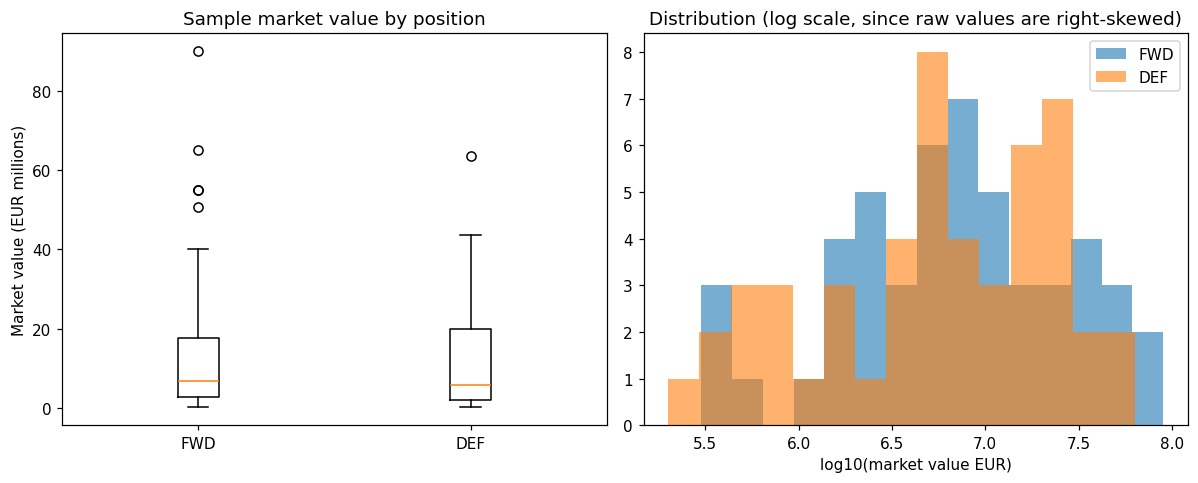

In [6]:
d_fwd = describe(fwd_sample, "Forwards (sample)")
d_def = describe(def_sample, "Defenders (sample)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].boxplot([fwd_sample / 1e6, def_sample / 1e6], tick_labels=["FWD", "DEF"])
axes[0].set_ylabel("Market value (EUR millions)")
axes[0].set_title("Sample market value by position")
axes[1].hist(np.log10(fwd_sample), bins=15, alpha=0.6, label="FWD")
axes[1].hist(np.log10(def_sample), bins=15, alpha=0.6, label="DEF")
axes[1].set_xlabel("log10(market value EUR)")
axes[1].set_title("Distribution (log scale, since raw values are right-skewed)")
axes[1].legend()
plt.tight_layout()
plt.show()

### 5. Inferential statistics — Confidence interval

95% confidence interval for the true mean market value of the forward
population.

In [7]:
ci_fwd = confidence_interval_mean(fwd_sample, confidence=0.95, label="Forwards mean market value")

[95% CI: Forwards mean market value] mean=14975825.22, SE=2788141.296, margin=5602979.706 -> (9372845.51, 20578804.93)


### 6. Inferential statistics — Two-sample t-test

H0: μ_FWD = μ_DEF   Ha: μ_FWD ≠ μ_DEF (two-tailed). Welch's t-test is used
because the two groups' sample variances are clearly unequal.

In [8]:
t1_result = two_sample_ttest(fwd_sample, def_sample, alternative="two-sided",
                              alpha=ALPHA, label="FWD vs DEF market value",
                              name_a="FWD", name_b="DEF")

direction = "higher" if d_fwd["mean"] > d_def["mean"] else "lower"
sig = "a statistically significant" if t1_result["reject_h0"] else "no statistically significant"
print(f"\nCONCLUSION: Forwards averaged a {direction} market value "
      f"(EUR {d_fwd['mean']:,.0f}) than defenders (EUR {d_def['mean']:,.0f}); "
      f"{sig} difference (p={t1_result['p_value']:.4f}).")

[Two-sample Welch t-test: FWD vs DEF market value] H0: mu_FWD = mu_DEF, alternative=two-sided
    FWD: n=50, mean=14975825.22 | DEF: n=50, mean=11716506.56
    t=0.968, p=0.3356 -> FAIL TO REJECT H0 at alpha=0.05

CONCLUSION: Forwards averaged a higher market value (EUR 14,975,825) than defenders (EUR 11,716,507); no statistically significant difference (p=0.3356).


## Task 2 — Experience: UEFA squads' caps vs a tournament benchmark

**Focal point:** player experience (international caps) — distinct from
market value (Task 1), match performance (Task 3) and age (Task 4).

### 1. Analytic question formulation

Do players from UEFA (European) squads at the FIFA World Cup 2026 average
significantly more international caps than the benchmark set by all
non-UEFA players?

### 2. Data wrangling

Merge the player list with team data to attach each player's confederation,
then split into UEFA vs non-UEFA.

In [9]:
teams = teams_raw.copy()
players = players.merge(teams[["team_id", "confederation"]], on="team_id", how="left")

uefa_pop = players.loc[players["confederation"] == "UEFA", "caps"]
non_uefa_pop = players.loc[players["confederation"] != "UEFA", "caps"]

### 3. Data preparation and sampling

**Population:** 416 UEFA players. The benchmark (35.10 caps) is the known,
fixed mean of the entire non-UEFA population — that fixed reference point
is what makes a **one-sample** t-test the right tool here, unlike Task 1's
two-sample comparison of two sampled groups.
**Sample:** simple random sample of n=40 UEFA players.

In [10]:
SAMPLE_SIZE_T2 = 40
benchmark = non_uefa_pop.mean()
print(f"Population: {len(uefa_pop)} UEFA players; benchmark (non-UEFA mean caps) = {benchmark:.2f}")

uefa_sample = uefa_pop.sample(n=SAMPLE_SIZE_T2, random_state=RANDOM_STATE)

Population: 416 UEFA players; benchmark (non-UEFA mean caps) = 35.10


### 4. Descriptive statistics

[Descriptive: UEFA players (sample)] n=40, mean=41.15, median=32.50, std=31.38, IQR=(16.50, 66.50), range=(1.00, 114.00)


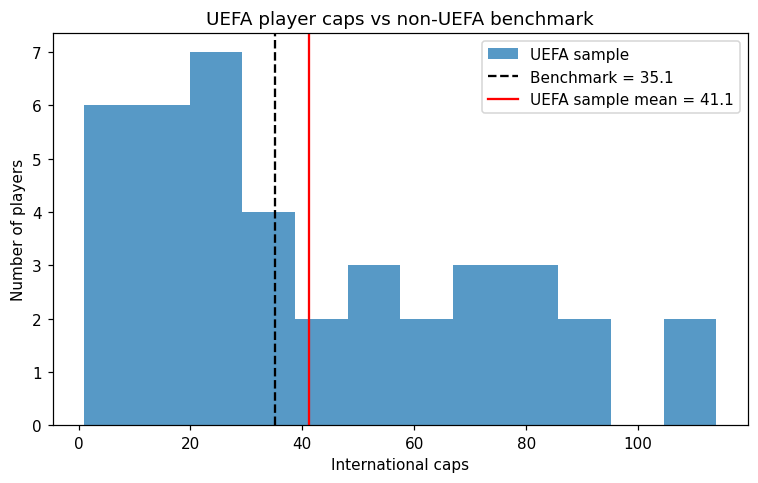

In [11]:
d_uefa = describe(uefa_sample, "UEFA players (sample)")

plt.figure(figsize=(7, 4.5))
plt.hist(uefa_sample, bins=12, alpha=0.75, label="UEFA sample")
plt.axvline(benchmark, color="black", linestyle="--", label=f"Benchmark = {benchmark:.1f}")
plt.axvline(d_uefa["mean"], color="red", label=f"UEFA sample mean = {d_uefa['mean']:.1f}")
plt.xlabel("International caps"); plt.ylabel("Number of players")
plt.title("UEFA player caps vs non-UEFA benchmark"); plt.legend()
plt.tight_layout(); plt.show()

### 5. Inferential statistics — Confidence interval

95% confidence interval for the true mean caps of the UEFA population.

In [12]:
ci_uefa = confidence_interval_mean(uefa_sample, confidence=0.95, label="UEFA mean caps")

[95% CI: UEFA mean caps] mean=41.15, SE=4.962, margin=10.037 -> (31.11, 51.19)


### 6. Inferential statistics — One-sample t-test

H0: μ_UEFA = benchmark   Ha: μ_UEFA ≠ benchmark (two-tailed).

In [13]:
t2_result = one_sample_ttest(uefa_sample, popmean=benchmark, alternative="two-sided",
                              alpha=ALPHA, label="UEFA caps vs non-UEFA benchmark")

direction = "higher" if d_uefa["mean"] > benchmark else "lower"
sig = "a statistically significant" if t2_result["reject_h0"] else "no statistically significant"
print(f"\nCONCLUSION: The UEFA sample averaged {d_uefa['mean']:.2f} caps, {direction} "
      f"than the {benchmark:.2f}-cap benchmark; {sig} difference "
      f"(p={t2_result['p_value']:.4f}).")

[One-sample t-test: UEFA caps vs non-UEFA benchmark] H0: mu = 35.10, alternative=two-sided
    n=40, sample mean=41.15, t=1.218, df=39, p=0.2304 -> FAIL TO REJECT H0 at alpha=0.05

CONCLUSION: The UEFA sample averaged 41.15 caps, higher than the 35.10-cap benchmark; no statistically significant difference (p=0.2304).


## Task 3 — Team performance: Possession in wins vs losses

**Focal point:** team-level match performance (possession %) — the only
task built from match-level, not player-level, data.

### 1. Analytic question formulation

Did teams that won their FIFA World Cup 2026 match have significantly
higher ball possession than teams that lost?

### 2. Data wrangling

Join per-team match statistics to match results, label each team-in-a-match
row Win/Loss/Draw, and drop invalid rows.

In [14]:
m_scores = matches_raw[["match_id", "home_team_id", "away_team_id", "home_score", "away_score"]]
team_match = team_match_stats_raw.merge(m_scores, on="match_id", how="left")

def _result(r):
    own, opp = (r["home_score"], r["away_score"]) if r["team_id"] == r["home_team_id"] else (r["away_score"], r["home_score"])
    return "Win" if own > opp else ("Loss" if own < opp else "Draw")

team_match["result"] = team_match.apply(_result, axis=1)

before = len(team_match)
team_match = team_match.dropna(subset=["possession_pct", "total_shots", "result"])
print(f"Dropped {before - len(team_match)} invalid row(s) -> {len(team_match)} team-match rows remain")
print(team_match["result"].value_counts())

Dropped 0 invalid row(s) -> 208 team-match rows remain
result
Win     80
Loss    80
Draw    48
Name: count, dtype: int64


### 3. Data preparation and sampling

**Population:** every team-in-a-match performance restricted to matches
with a clear winner/loser — draws excluded (80 winning, 80 losing
team-performances from the 80 decisive matches).
**Sample:** simple random sample of n=30 from each group.

In [15]:
SAMPLE_SIZE_T3 = 30
decisive = team_match[team_match["result"] != "Draw"]
win_pop = decisive.loc[decisive["result"] == "Win", "possession_pct"]
loss_pop = decisive.loc[decisive["result"] == "Loss", "possession_pct"]
print(f"Population (decisive matches only): {len(win_pop)} winning, {len(loss_pop)} losing team-performances")

win_sample = win_pop.sample(n=SAMPLE_SIZE_T3, random_state=RANDOM_STATE)
loss_sample = loss_pop.sample(n=SAMPLE_SIZE_T3, random_state=RANDOM_STATE)

Population (decisive matches only): 80 winning, 80 losing team-performances


### 4. Descriptive statistics

[Descriptive: Winning teams (sample)] n=30, mean=55.27, median=58.00, std=10.55, IQR=(49.25, 62.00), range=(27.00, 71.00)
[Descriptive: Losing teams (sample)] n=30, mean=43.27, median=41.50, std=10.57, IQR=(38.00, 49.50), range=(20.00, 68.00)


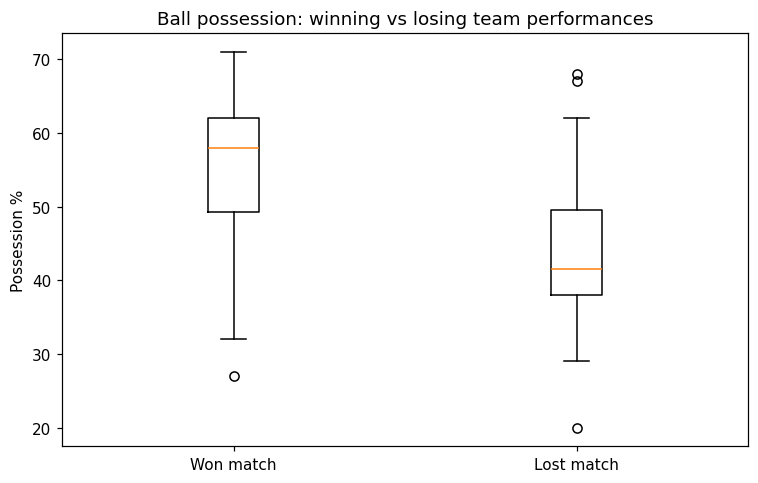

In [16]:
d_win = describe(win_sample, "Winning teams (sample)")
d_loss = describe(loss_sample, "Losing teams (sample)")

plt.figure(figsize=(7, 4.5))
plt.boxplot([win_sample, loss_sample], tick_labels=["Won match", "Lost match"])
plt.ylabel("Possession %"); plt.title("Ball possession: winning vs losing team performances")
plt.tight_layout(); plt.show()

### 5. Inferential statistics — Confidence interval

95% confidence interval for the true mean possession of winning teams.

In [17]:
ci_win = confidence_interval_mean(win_sample, confidence=0.95, label="Winning teams mean possession")

[95% CI: Winning teams mean possession] mean=55.27, SE=1.926, margin=3.939 -> (51.33, 59.21)


### 6. Inferential statistics — Two-sample t-test

H0: μ_Win = μ_Loss   Ha: μ_Win > μ_Loss (one-tailed — football theory gives
us a specific expected direction here).

In [18]:
t3_result = two_sample_ttest(win_sample, loss_sample, alternative="greater",
                              alpha=ALPHA, label="Winners vs losers possession",
                              name_a="Win", name_b="Loss")

sig = "a statistically significant" if t3_result["reject_h0"] else "no statistically significant"
print(f"\nCONCLUSION: Winning teams averaged {d_win['mean']:.1f}% possession vs "
      f"{d_loss['mean']:.1f}% for losing teams; {sig} difference "
      f"(p={t3_result['p_value']:.4f}).")

[Two-sample Welch t-test: Winners vs losers possession] H0: mu_Win = mu_Loss, alternative=greater
    Win: n=30, mean=55.27 | Loss: n=30, mean=43.27
    t=4.400, p=0.0000 -> REJECT H0 at alpha=0.05

CONCLUSION: Winning teams averaged 55.3% possession vs 43.3% for losing teams; a statistically significant difference (p=0.0000).


## Task 4 — Demographics: Goalkeeper age vs outfield player age

**Focal point:** player age/demographics — distinct from market value
(Task 1), experience (Task 2) and match performance (Task 3).

### 1. Analytic question formulation

Are goalkeepers at the FIFA World Cup 2026 significantly older, on
average, than outfield players (defenders, midfielders, forwards
combined)?

### 2. Data wrangling

Compute each player's age at the tournament's opening match (11 June 2026)
from their date of birth, then split goalkeepers vs all outfield positions.

In [19]:
TOURNAMENT_START = pd.Timestamp("2026-06-11")

players["date_of_birth"] = pd.to_datetime(players["date_of_birth"])
players["age_years"] = (TOURNAMENT_START - players["date_of_birth"]).dt.days / 365.25

before = len(players)
players_valid = players[players["age_years"].between(15, 45)]
print(f"Dropped {before - len(players_valid)} implausible-age row(s) -> {len(players_valid)} remain")

gk_pop = players_valid.loc[players_valid["position"] == "GK", "age_years"]
outfield_pop = players_valid.loc[players_valid["position"] != "GK", "age_years"]

Dropped 0 implausible-age row(s) -> 1248 remain


### 3. Data preparation and sampling

**Population:** 145 goalkeepers, 1,103 outfield players.
**Sample:** simple random sample of n=40 from each.

In [20]:
SAMPLE_SIZE_T4 = 40
print(f"Population: {len(gk_pop)} goalkeepers, {len(outfield_pop)} outfield players")

gk_sample = gk_pop.sample(n=SAMPLE_SIZE_T4, random_state=RANDOM_STATE)
outfield_sample = outfield_pop.sample(n=SAMPLE_SIZE_T4, random_state=RANDOM_STATE)

Population: 145 goalkeepers, 1103 outfield players


### 4. Descriptive statistics

[Descriptive: Goalkeepers (sample)] n=40, mean=28.94, median=27.83, std=4.55, IQR=(26.05, 32.40), range=(18.68, 39.01)
[Descriptive: Outfield players (sample)] n=40, mean=28.54, median=27.34, std=4.73, IQR=(25.12, 32.18), range=(20.26, 38.48)


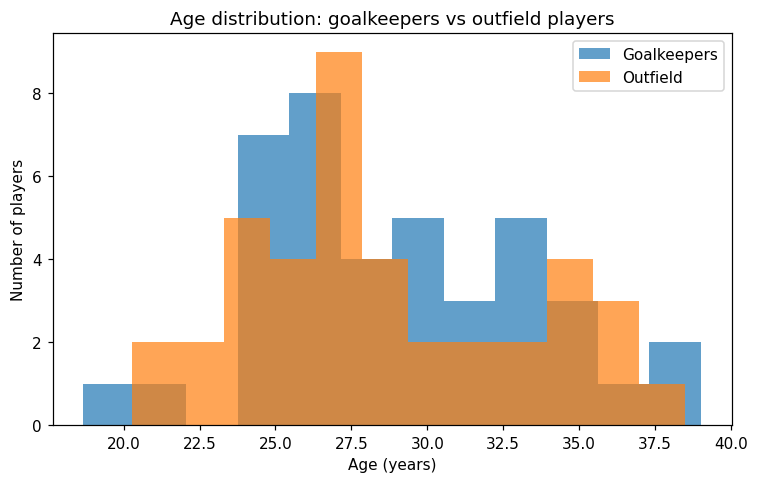

In [21]:
d_gk = describe(gk_sample, "Goalkeepers (sample)")
d_out = describe(outfield_sample, "Outfield players (sample)")

plt.figure(figsize=(7, 4.5))
plt.hist(gk_sample, bins=12, alpha=0.7, label="Goalkeepers")
plt.hist(outfield_sample, bins=12, alpha=0.7, label="Outfield")
plt.xlabel("Age (years)"); plt.ylabel("Number of players")
plt.title("Age distribution: goalkeepers vs outfield players"); plt.legend()
plt.tight_layout(); plt.show()

### 5. Inferential statistics — Confidence interval

95% confidence interval for the true mean age of the goalkeeper population.

In [22]:
ci_gk = confidence_interval_mean(gk_sample, confidence=0.95, label="Goalkeepers mean age")

[95% CI: Goalkeepers mean age] mean=28.94, SE=0.720, margin=1.455 -> (27.48, 30.40)


### 6. Inferential statistics — Two-sample t-test

H0: μ_GK = μ_Outfield   Ha: μ_GK > μ_Outfield (one-tailed — goalkeepers are
widely believed to have longer careers / peak later).

In [23]:
t4_result = two_sample_ttest(gk_sample, outfield_sample, alternative="greater",
                              alpha=ALPHA, label="GK vs Outfield age",
                              name_a="GK", name_b="Outfield")

sig = "a statistically significant" if t4_result["reject_h0"] else "no statistically significant"
print(f"\nCONCLUSION: Goalkeepers averaged {d_gk['mean']:.1f} years vs "
      f"{d_out['mean']:.1f} years for outfield players; {sig} difference "
      f"(p={t4_result['p_value']:.4f}).")

[Two-sample Welch t-test: GK vs Outfield age] H0: mu_GK = mu_Outfield, alternative=greater
    GK: n=40, mean=28.94 | Outfield: n=40, mean=28.54
    t=0.386, p=0.3503 -> FAIL TO REJECT H0 at alpha=0.05

CONCLUSION: Goalkeepers averaged 28.9 years vs 28.5 years for outfield players; no statistically significant difference (p=0.3503).


### Objective 1 — cross-task takeaways
- Only **Task 3** (possession vs match outcome) was statistically
  significant — a reminder that a well-formed question doesn't guarantee a
  significant result, and that's a legitimate, honest finding.
- Welch's t-test (unequal variances) was used throughout since none of the
  compared groups had equal variances.
- One-tailed tests (Tasks 3, 4) were used only where domain knowledge gave
  a specific expected direction in advance; two-tailed tests (Tasks 1, 2)
  were used where no strong prior direction existed.

---
# Objective 2 — Two Linear Regression Tasks

Both models use **only pre-match information** (pre-tournament rankings,
Elo ratings, squad composition, schedule/stage, host-nation status) —
never anything derived from in-match events (shots, possession, cards,
etc.), per the assignment's explicit constraint.

## Build the regression datasets

Shared squad-level aggregates (computed from the player list, so they're
known before a ball is kicked) and an `is_knockout` flag per match.

In [24]:
HOST_CODES = {"MEX", "USA", "CAN"}

squad_agg = players.groupby("team_id").agg(
    avg_market_value_eur=("market_value_eur", "mean"),
    avg_caps=("caps", "mean"),
    avg_age=("age_years", "mean"),
).reset_index()

teams["is_host"] = teams["fifa_code"].isin(HOST_CODES).astype(int)
team_ref = teams.merge(squad_agg, on="team_id", how="left")[
    ["team_id", "team_name", "fifa_code", "confederation",
     "fifa_ranking_pre_tournament", "elo_rating", "is_host",
     "avg_market_value_eur", "avg_caps", "avg_age"]
]

stage_flags = tournament_stages[["stage_id", "is_knockout"]]
matches = matches_raw.merge(stage_flags, on="stage_id", how="left")

print(team_ref.head())

   team_id     team_name fifa_code confederation  fifa_ranking_pre_tournament  \
0        1        Mexico       MEX      CONCACAF                           14   
1        2  South Africa       RSA           CAF                           60   
2        3   South Korea       KOR           AFC                           22   
3        4       Czechia       CZE          UEFA                           40   
4        5        Canada       CAN      CONCACAF                           33   

   elo_rating  is_host  avg_market_value_eur   avg_caps    avg_age  
0        1810        1          1.584256e+07  47.576923  27.900700  
1        1620        0          1.834615e+06  20.692308  26.808403  
2        1800        0          5.348077e+06  37.461538  28.065708  
3        1740        0          7.197763e+06  28.384615  27.620808  
4        1795        1          7.855136e+06  37.423077  26.972674  


## Linear Regression 2.1 — Predicting match goal difference

**104 rows** (one per match). Target: `goal_difference = home_score -
away_score`. Exactly **8** pre-match explanatory variables:

| Variable | Meaning |
|---|---|
| `elo_diff` | Elo rating gap (home − away) |
| `fifa_ranking_diff` | Pre-tournament FIFA ranking gap (away − home; positive = home team ranked better) |
| `squad_value_diff_eur_m` | Average squad market value gap, EUR millions (home − away) |
| `squad_experience_diff` | Average squad caps gap (home − away) |
| `squad_age_diff` | Average squad age gap (home − away) |
| `is_knockout` | 1 if a knockout-stage match, else 0 |
| `host_advantage` | +1 home team is a host nation, −1 away team is, 0 neither |
| `same_confederation` | 1 if both teams share a confederation, else 0 |

In [25]:
df1 = matches.merge(team_ref.add_prefix("home_"), left_on="home_team_id", right_on="home_team_id", how="left")
df1 = df1.merge(team_ref.add_prefix("away_"), left_on="away_team_id", right_on="away_team_id", how="left")

reg1 = pd.DataFrame({"match_id": df1["match_id"]})
reg1["goal_difference"] = df1["home_score"] - df1["away_score"]
reg1["elo_diff"] = df1["home_elo_rating"] - df1["away_elo_rating"]
reg1["fifa_ranking_diff"] = df1["away_fifa_ranking_pre_tournament"] - df1["home_fifa_ranking_pre_tournament"]
reg1["squad_value_diff_eur_m"] = (df1["home_avg_market_value_eur"] - df1["away_avg_market_value_eur"]) / 1e6
reg1["squad_experience_diff"] = df1["home_avg_caps"] - df1["away_avg_caps"]
reg1["squad_age_diff"] = df1["home_avg_age"] - df1["away_avg_age"]
reg1["is_knockout"] = df1["is_knockout"].astype(int)
reg1["host_advantage"] = df1["home_is_host"] - df1["away_is_host"]
reg1["same_confederation"] = (df1["home_confederation"] == df1["away_confederation"]).astype(int)

assert reg1.shape[0] == 104, reg1.shape
FEATURES_1 = ["elo_diff", "fifa_ranking_diff", "squad_value_diff_eur_m",
              "squad_experience_diff", "squad_age_diff", "is_knockout",
              "host_advantage", "same_confederation"]
assert len(FEATURES_1) == 8
print("Regression dataset 2.1:", reg1.shape, "| explanatory variables:", len(FEATURES_1))
reg1.head()

Regression dataset 2.1: (104, 10) | explanatory variables: 8


,match_id,goal_difference,elo_diff,fifa_ranking_diff,squad_value_diff_eur_m,squad_experience_diff,squad_age_diff,is_knockout,host_advantage,same_confederation
0,1,2,190,46,14.007943,26.884615,1.092297,0,1,0
1,2,1,60,18,-1.849686,9.076923,0.444901,0,0,0
2,3,0,150,31,2.224366,13.846154,0.516190,0,1,0
3,4,3,125,37,9.649615,10.461538,-2.097615,0,1,0
4,5,0,-260,-37,-9.072482,16.846154,1.200653,0,0,0


                            OLS Regression Results                            
Dep. Variable:        goal_difference   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     11.47
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           2.93e-11
Time:                        00:30:51   Log-Likelihood:                -185.26
No. Observations:                 104   AIC:                             388.5
Df Residuals:                      95   BIC:                             412.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0

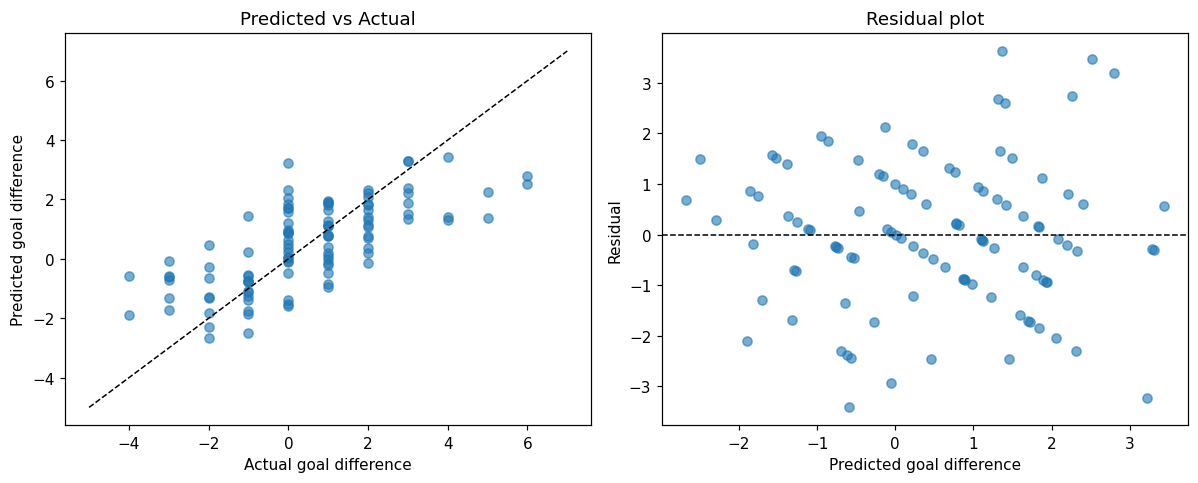


CONCLUSION:
Full-data OLS R^2=0.491 (adj=0.448). 5-fold CV mean R^2=0.328, mean MAE=1.23 goals.


In [26]:
X1 = reg1[FEATURES_1].astype(float)
y1 = reg1["goal_difference"].astype(float)

# Standardise for OLS interpretation (raw variables sit on very different
# scales -- Elo points vs EUR millions vs 0/1 flags). Does not change
# predictions, R^2 or MAE.
scaler1 = StandardScaler()
X1_scaled = pd.DataFrame(scaler1.fit_transform(X1), columns=X1.columns)
ols1 = sm.OLS(y1, sm.add_constant(X1_scaled)).fit()
print(ols1.summary())

lr1 = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
r2_1 = cross_val_score(lr1, X1, y1, cv=kf, scoring="r2")
mae_1 = -cross_val_score(lr1, X1, y1, cv=kf, scoring="neg_mean_absolute_error")
print(f"\n5-fold CV R^2: mean={r2_1.mean():.3f}, std={r2_1.std():.3f}")
print(f"5-fold CV MAE: mean={mae_1.mean():.3f} goals, std={mae_1.std():.3f}")

lr1.fit(X1, y1)
pred1 = lr1.predict(X1)
resid1 = y1 - pred1

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(y1, pred1, alpha=0.6)
lims = [min(y1.min(), pred1.min()) - 1, max(y1.max(), pred1.max()) + 1]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("Actual goal difference"); axes[0].set_ylabel("Predicted goal difference")
axes[0].set_title("Predicted vs Actual")
axes[1].scatter(pred1, resid1, alpha=0.6)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted goal difference"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual plot")
plt.tight_layout(); plt.show()

print("\nCONCLUSION:")
print(f"Full-data OLS R^2={ols1.rsquared:.3f} (adj={ols1.rsquared_adj:.3f}). "
      f"5-fold CV mean R^2={r2_1.mean():.3f}, mean MAE={mae_1.mean():.2f} goals.")

## Linear Regression 2.2 — Predicting a team's goals in a match

**208 rows** (one per team-in-a-match). Target: `team_goals` = goals
scored by that team in that match. Exactly **8** pre-match explanatory
variables:

| Variable | Meaning |
|---|---|
| `team_elo_rating` | This team's Elo rating |
| `opponent_elo_rating` | The opponent's Elo rating |
| `team_fifa_ranking` | This team's pre-tournament FIFA ranking |
| `opponent_fifa_ranking` | Opponent's pre-tournament FIFA ranking |
| `team_avg_market_value_eur_m` | Average squad market value, EUR millions (this team) |
| `team_avg_caps` | Average squad international caps (this team) |
| `is_host_advantage` | 1 if this team is a host nation, else 0 |
| `is_knockout` | 1 if a knockout-stage match, else 0 |

In [27]:
rows = []
for _, m in matches.iterrows():
    for side, opp_side in [("home", "away"), ("away", "home")]:
        team_id = m[f"{side}_team_id"]
        opp_id = m[f"{opp_side}_team_id"]
        t = team_ref.loc[team_ref["team_id"] == team_id].iloc[0]
        o = team_ref.loc[team_ref["team_id"] == opp_id].iloc[0]
        rows.append({
            "match_id": m["match_id"], "team_id": team_id,
            "team_goals": m[f"{side}_score"],
            "team_elo_rating": t["elo_rating"],
            "opponent_elo_rating": o["elo_rating"],
            "team_fifa_ranking": t["fifa_ranking_pre_tournament"],
            "opponent_fifa_ranking": o["fifa_ranking_pre_tournament"],
            "team_avg_market_value_eur_m": t["avg_market_value_eur"] / 1e6,
            "team_avg_caps": t["avg_caps"],
            "is_host_advantage": int(t["is_host"]),
            "is_knockout": int(m["is_knockout"]),
        })

reg2 = pd.DataFrame(rows)
assert reg2.shape[0] == 208, reg2.shape
FEATURES_2 = ["team_elo_rating", "opponent_elo_rating", "team_fifa_ranking",
              "opponent_fifa_ranking", "team_avg_market_value_eur_m",
              "team_avg_caps", "is_host_advantage", "is_knockout"]
assert len(FEATURES_2) == 8
print("Regression dataset 2.2:", reg2.shape, "| explanatory variables:", len(FEATURES_2))
reg2.head()

Regression dataset 2.2: (208, 11) | explanatory variables: 8


,match_id,team_id,team_goals,team_elo_rating,opponent_elo_rating,team_fifa_ranking,opponent_fifa_ranking,team_avg_market_value_eur_m,team_avg_caps,is_host_advantage,is_knockout
0,1,1,2,1810,1620,14,60,15.842558,47.576923,1,0
1,1,2,0,1620,1810,60,14,1.834615,20.692308,0,0
2,2,3,2,1800,1740,22,40,5.348077,37.461538,0,0
3,2,4,1,1740,1800,40,22,7.197763,28.384615,0,0
4,3,5,1,1795,1645,33,64,7.855136,37.423077,1,0


                            OLS Regression Results                            
Dep. Variable:             team_goals   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     9.128
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           1.14e-10
Time:                        00:30:51   Log-Likelihood:                -331.14
No. Observations:                 208   AIC:                             680.3
Df Residuals:                     199   BIC:                             710.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

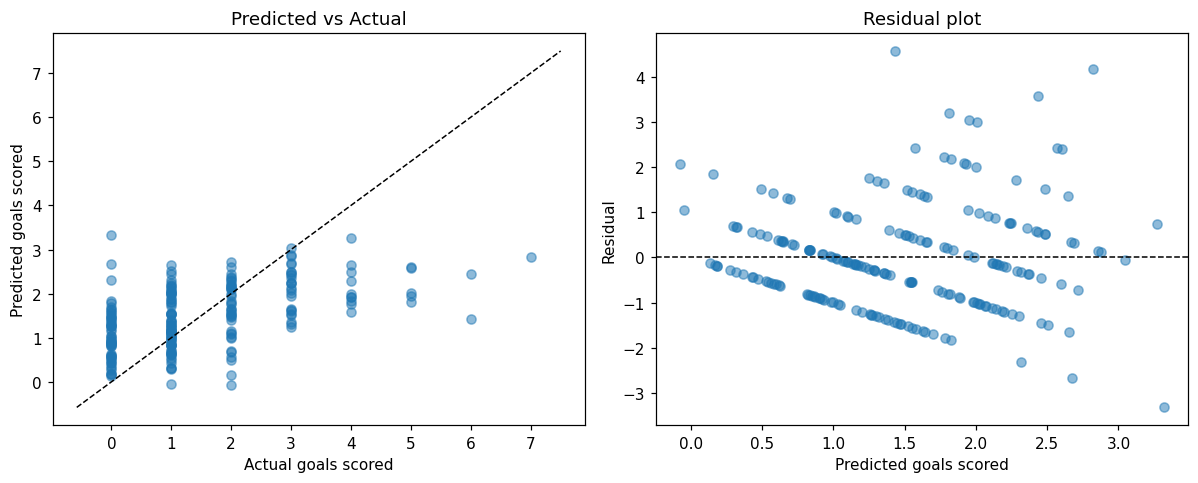


CONCLUSION:
Full-data OLS R^2=0.268 (adj=0.239). 5-fold CV mean R^2=0.163, mean MAE=0.95 goals. Single-match goals are noisy/discrete (Poisson-like), so a linear model will never fit as tightly as it would for a smoother outcome.


In [28]:
X2 = reg2[FEATURES_2].astype(float)
y2 = reg2["team_goals"].astype(float)

scaler2 = StandardScaler()
X2_scaled = pd.DataFrame(scaler2.fit_transform(X2), columns=X2.columns)
ols2 = sm.OLS(y2, sm.add_constant(X2_scaled)).fit()
print(ols2.summary())

lr2 = LinearRegression()
r2_2 = cross_val_score(lr2, X2, y2, cv=kf, scoring="r2")
mae_2 = -cross_val_score(lr2, X2, y2, cv=kf, scoring="neg_mean_absolute_error")
print(f"\n5-fold CV R^2: mean={r2_2.mean():.3f}, std={r2_2.std():.3f}")
print(f"5-fold CV MAE: mean={mae_2.mean():.3f} goals, std={mae_2.std():.3f}")

lr2.fit(X2, y2)
pred2 = lr2.predict(X2)
resid2 = y2 - pred2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(y2, pred2, alpha=0.5)
lims = [min(y2.min(), pred2.min()) - 0.5, max(y2.max(), pred2.max()) + 0.5]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("Actual goals scored"); axes[0].set_ylabel("Predicted goals scored")
axes[0].set_title("Predicted vs Actual")
axes[1].scatter(pred2, resid2, alpha=0.5)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted goals scored"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual plot")
plt.tight_layout(); plt.show()

print("\nCONCLUSION:")
print(f"Full-data OLS R^2={ols2.rsquared:.3f} (adj={ols2.rsquared_adj:.3f}). "
      f"5-fold CV mean R^2={r2_2.mean():.3f}, mean MAE={mae_2.mean():.2f} goals. "
      f"Single-match goals are noisy/discrete (Poisson-like), so a linear "
      f"model will never fit as tightly as it would for a smoother outcome.")

---
# Overall Conclusion & Lessons Learned

- Of the four Objective 1 hypotheses, only **possession vs match outcome**
  (Task 3) was statistically significant.
- Both Objective 2 regression models achieved a moderate, honest fit
  (goal difference: CV R² ≈ 0.33; team goals: CV R² ≈ 0.16) using only
  pre-match information — realistic for a genuinely uncertain sporting
  outcome.
- Every inferential decision — Welch's vs Student's t-test, one-tailed vs
  two-tailed, sampling technique, choice of pre-match variables — was made
  deliberately and is documented above.

**Remember:** every team member should be able to explain any part of this
notebook in their own words, and your AI Usage Declaration Form should
honestly reflect how this notebook was produced.